# Project: Heart Disease Prediction using Machine Learning Techniques

## Abstract
Cardiovascular diseases are among the leading causes of death globally, and early detection plays a vital role in reducing risk and improving patient outcomes. This project aims to develop a machine learning model that predicts the presence of heart disease using the Cleveland subset of the UCI Heart Disease dataset. The dataset contains 303 patient records with 13 clinical attributes, including age, sex, chest pain type, resting blood pressure, cholesterol levels, maximum heart rate, and exercise-induced angina.

The primary task is binary classification: distinguishing between patients with and without heart disease. The project follows a complete machine learning pipeline, including data preprocessing, handling missing values, exploratory data analysis, feature engineering, model training, and evaluation. Multiple algorithms such as Logistic Regression, Random Forest, Support Vector Machine, and Gradient Boosting are applied and compared using metrics like accuracy, precision, recall, F1-score, and ROC-AUC.

The expected outcome is a robust predictive model that can assist healthcare professionals in identifying high-risk patients more efficiently. Additionally, feature importance analysis will highlight the most influential risk factors, providing valuable insights into cardiovascular health. This project demonstrates the potential of machine learning in medical diagnosis and decision support systems.

### 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

### 2. Load Dataset

In [ ]:
# URL for the Cleveland Heart Disease dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Column names as per UCI dataset description
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load the dataset, specifying '?' as missing values
df = pd.read_csv(url, names=column_names, na_values='?')

# Display the first few rows and basic info
print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values (before handling '?' in ca and thal):")
print(df.isnull().sum())

# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

Dataset Head:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Missing Values (before handling '?' in ca and thal):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope     

### 3. Handle Missing Values and Data Types

Some columns (`ca` and `thal`) have `?` as missing values and were loaded as objects. We will convert them to numeric and then impute any missing values.

In [ ]:
# 'ca' and 'thal' were loaded as objects due to '?' values. Convert them to numeric first.
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

# Now, impute missing values using the mean strategy
imputer = SimpleImputer(strategy='mean')

# Apply imputer to the entire DataFrame
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Check for missing values again
print("Missing Values (after imputation):")
print(df_imputed.isnull().sum())

df = df_imputed.copy()

# Ensure 'ca' and 'thal' are integer types after imputation if appropriate
df['ca'] = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)

print("\nDataset Info after imputation and type conversion:")
df.info()

print("\nDataset Head after processing:")
display(df.head())

Missing Values (after imputation):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dataset Info after imputation and type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target   

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0,6,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3,3,1.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2,7,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0,3,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0,3,0.0


### 4. Exploratory Data Analysis (EDA)

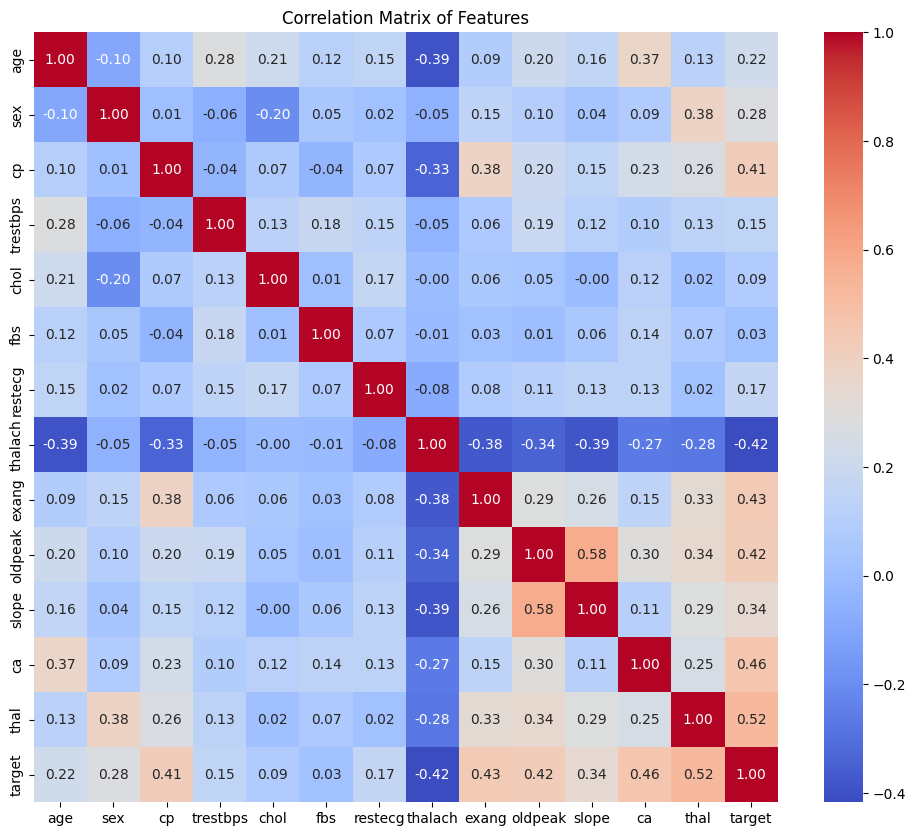

In [ ]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

/tmp/ipykernel_5639/3806985490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


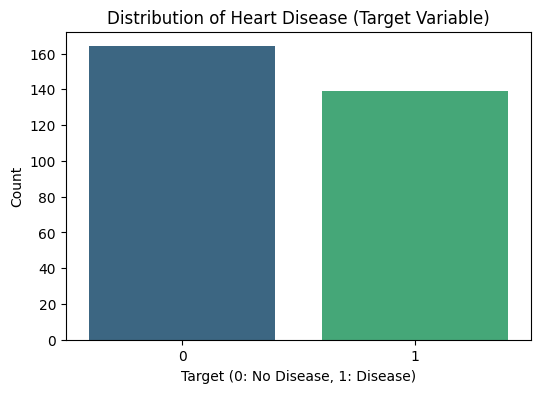

In [ ]:
# Distribution of Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Target (0: No Disease, 1: Disease)')
plt.ylabel('Count')
plt.show()

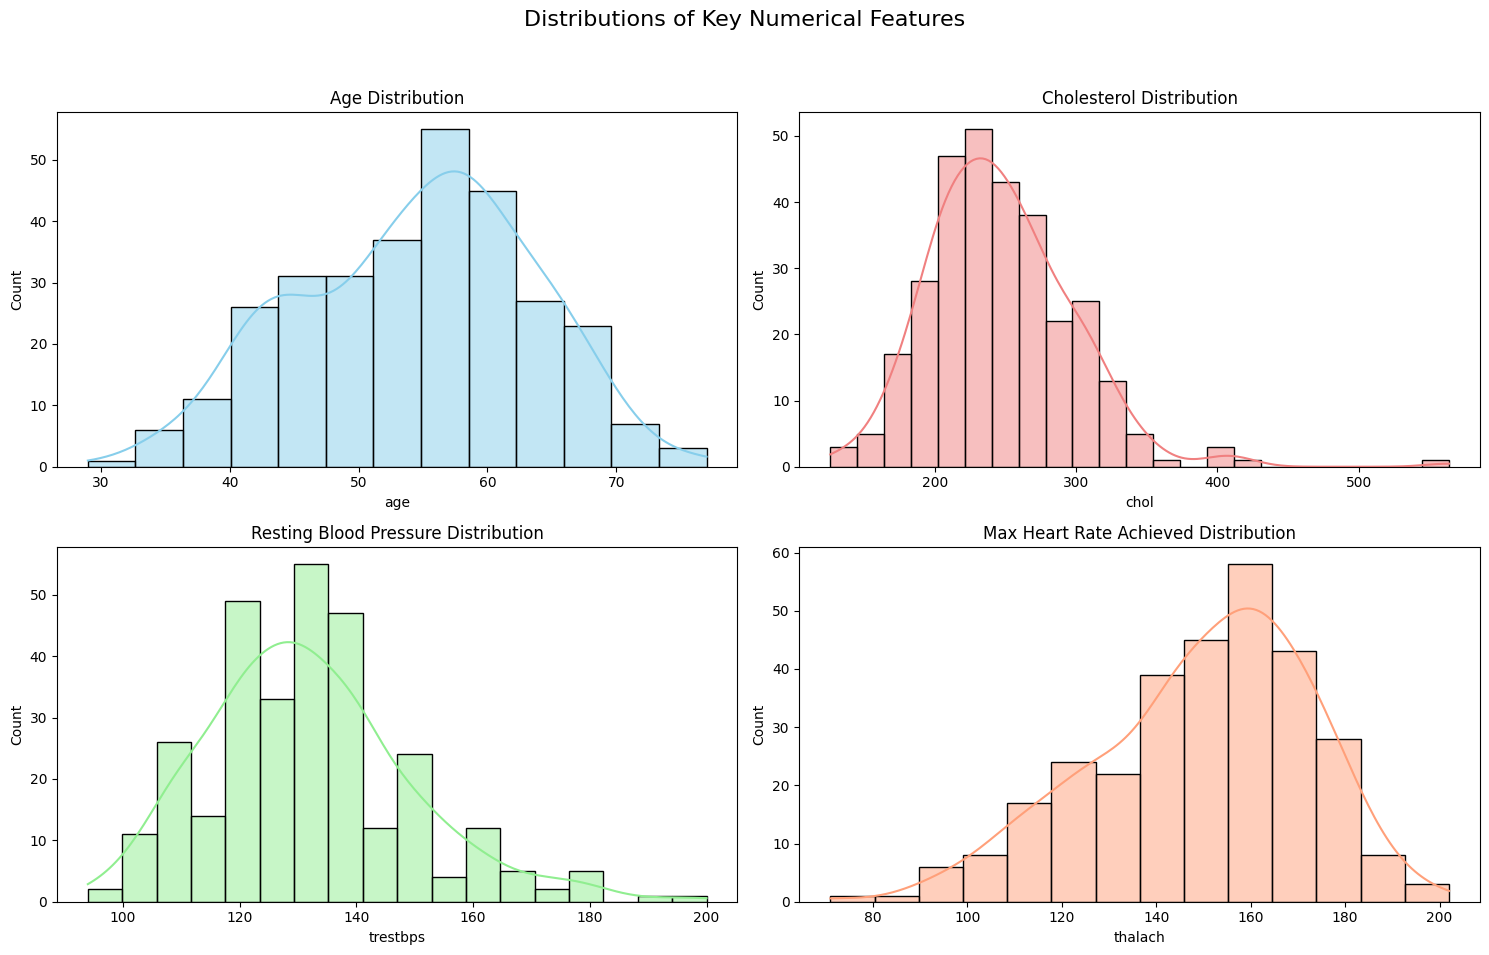

In [ ]:
# Distributions of Key Numerical Features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle('Distributions of Key Numerical Features', fontsize=16)

sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['chol'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Cholesterol Distribution')

sns.histplot(df['trestbps'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Resting Blood Pressure Distribution')

sns.histplot(df['thalach'], kde=True, ax=axes[1, 1], color='lightsalmon')
axes[1, 1].set_title('Max Heart Rate Achieved Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5. Feature & Target Split

In [ ]:
X = df.drop("target", axis=1) # Features
y = df["target"]             # Target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (303, 13)
Target (y) shape: (303,)


### 6. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # Stratify to maintain target distribution
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)


### 7. Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


### 8. Define Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'), # liblinear is good for small datasets
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Models defined.")

Models defined.


### 9. Train & Evaluate Models

In [ ]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Store predictions
    predictions[name] = y_pred

    # Probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = [0] * len(y_test) # Fallback for models without predict_proba if needed (e.g., some SVC configs)

    # Store probabilities
    probabilities[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan # Ensure ROC can be calculated

    results.append([name, acc, prec, rec, f1, roc])

    print(f"--- {name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Training Logistic Regression...
--- Logistic Regression Results ---
Accuracy: 0.8689
Precision: 0.8125
Recall: 0.9286
F1-Score: 0.8667
ROC-AUC: 0.9513
Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.82      0.87        33
         1.0       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Training Random Forest...
--- Random Forest Results ---
Accuracy: 0.8852
Precision: 0.8387
Recall: 0.9286
F1-Score: 0.8814
ROC-AUC: 0.9535
Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.85      0.89        33
         1.0       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61


Trainin

### 10. Compare Model Results

In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"
])

print("\nModel Comparison:")
display(results_df.sort_values(by='ROC-AUC', ascending=False))


Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.885246,0.838710,0.928571,0.881356,0.953463
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
3,Gradient Boosting,0.819672,0.742857,0.928571,0.825397,0.946970
2,SVM,0.852459,0.806452,0.892857,0.847458,0.943723


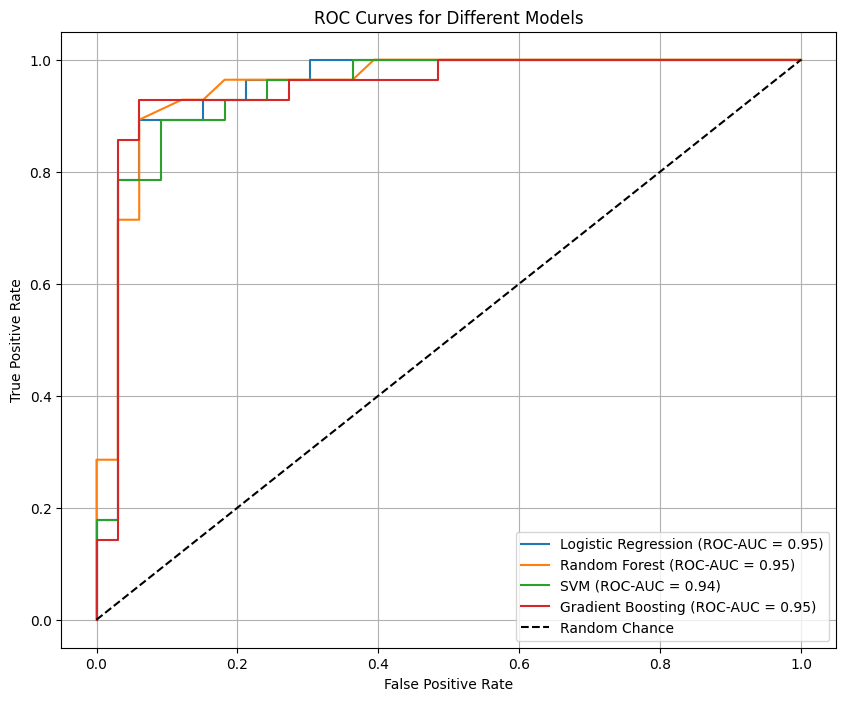

In [ ]:
# Visualize Model Performance (ROC Curves)
plt.figure(figsize=(10, 8))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (ROC-AUC = {results_df[results_df["Model"] == name]["ROC-AUC"].values[0]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.grid(True)
plt.show()

### 11. Feature Importance (Random Forest)

In [ ]:
rf_model = models["Random Forest"]

# Ensure the model is trained before getting feature importances
# (It was trained in step 9, but re-fit here for clarity if this cell is run standalone)
rf_model.fit(X_train_scaled, y_train)

importance = rf_model.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Random Forest Classifier):")
display(feature_importance_df)


Feature Importance (Random Forest Classifier):


,Feature,Importance
7,thalach,0.134399
12,thal,0.126060
2,cp,0.125141
11,ca,0.101010
0,age,0.090969
4,chol,0.090080
9,oldpeak,0.088782
3,trestbps,0.077408
8,exang,0.050451
10,slope,0.046784


/tmp/ipykernel_4402/2265752172.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette='viridis')


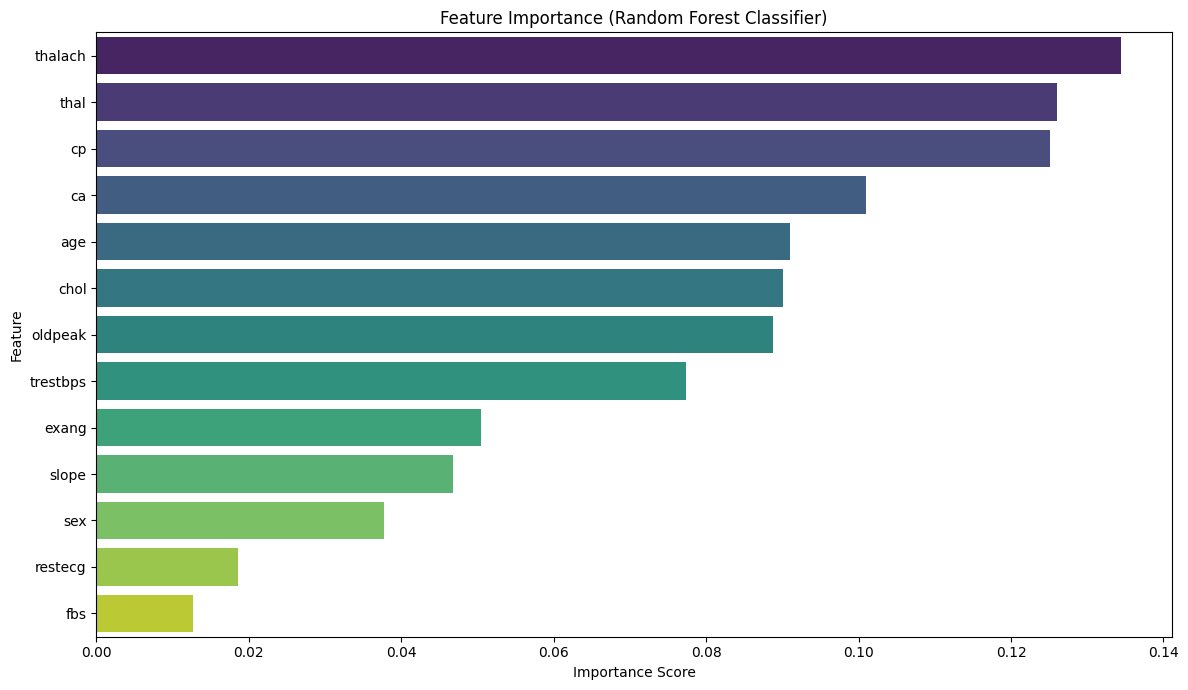

In [ ]:
# Visualize Feature Importance
plt.figure(figsize=(12, 7))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette='viridis')
plt.title("Feature Importance (Random Forest Classifier)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
#thank you